In [1]:
"""
Testing the fb_tools functions
"""

# standard imports
import os
import geopandas as gpd
import pandas as pd

from pathlib import Path
from os.path import join

# Import fb_tools (!!)
from fb_tools import lfps_request, run_flammap_scenarios, list_files

# directories
# use the current working directory
projdir = Path.cwd().parents[1] # moves up two, outside code directory
print(f"Project directory set to: {projdir}")
print(os.getcwd())

# environ vars
proj_crs = 26913  # NAD83 UTM Zone 13N

print("Ready to go !")

Project directory set to: \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper
\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\code\Python
Ready to go !


<Axes: >

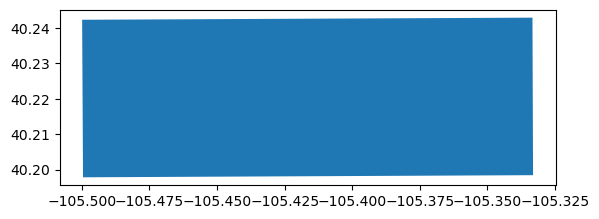

In [2]:
# --- Load a test AOI
fp = os.path.join(projdir, 'data/spatial/raw/test_aois.gpkg')
aoi = gpd.read_file(fp, layer='button_rock')
aoi.plot()

## lfps_request module

\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data/spatial/mod/fuelscapes/baseline\lcp_baseline.tif


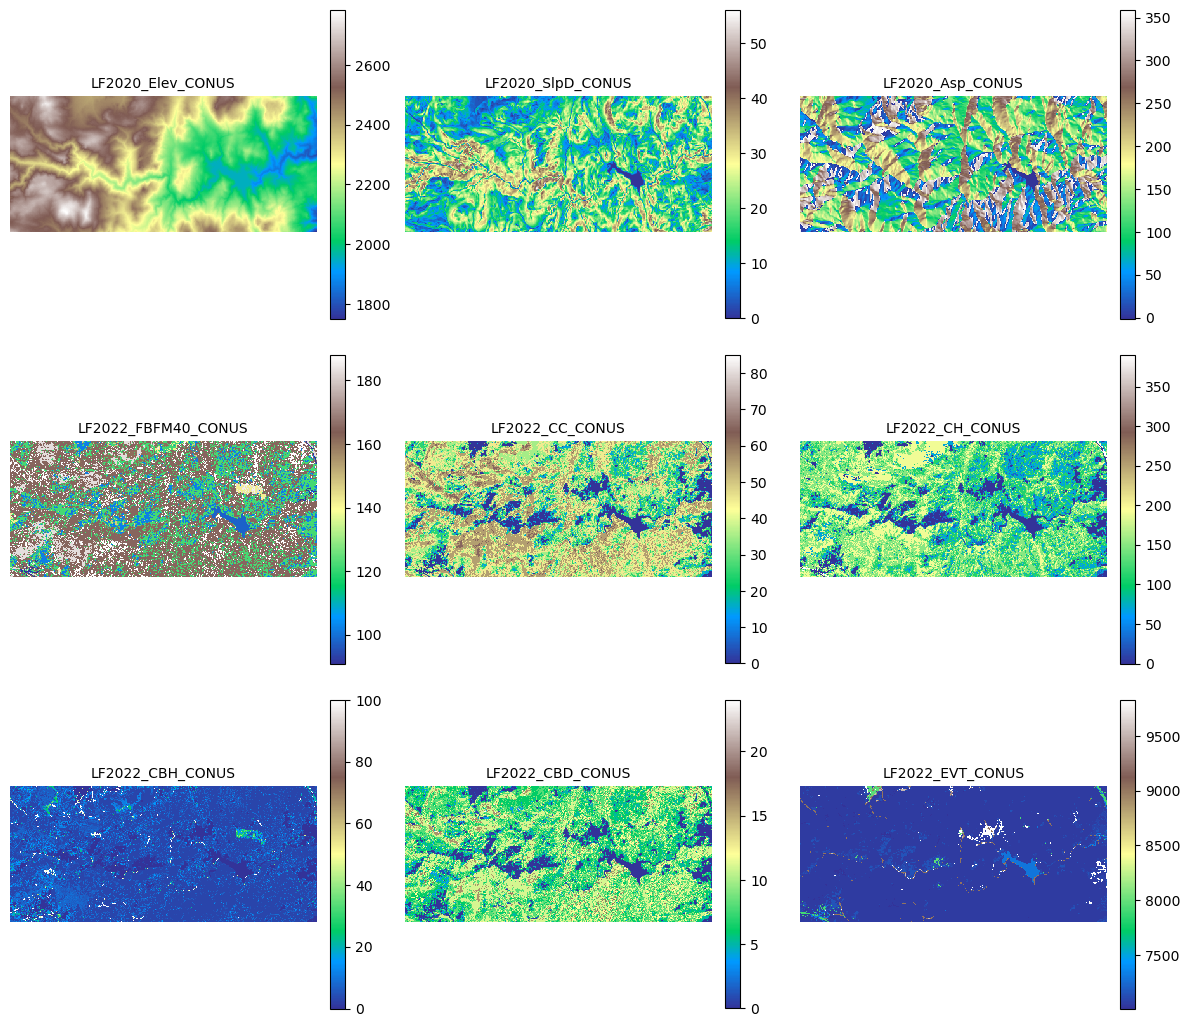

In [3]:
# --- Run a request to LFPS
out_fp = os.path.join(projdir, 'data/spatial/mod/fuelscapes/baseline')
rename='lcp_baseline'
runit=False # set to True to re-run
if not os.path.exists(join(out_fp, f"{rename}.tif")) or runit is True:
    lcp_da = lfps_request(
        region=aoi,
        out_dir=out_fp,
        lf_year='2022',
        lodgepole_adjust=True,
        rename=rename
    )
else:
    lcp_da = join(out_fp,f'{rename}.tif')
print(lcp_da)

from fb_tools import plot_bands

fig, axes = plot_bands(lcp_da)

## apply_treatment module

In [4]:
# --- Run fuel modifications for low, moderate, and high-severity wildfire

from fb_tools import apply_treatment

# load the canopy and surface modifications tables
canopy  = pd.read_csv(projdir / "data/tabular/raw/fuel_mods/canopy_effects.csv")
surface = pd.read_csv(projdir / "data/tabular/raw/fuel_mods/surface_effects.csv")
print(f"Treatments: {canopy.Treatment.unique()}")

# --- Landscape-scale (treat every pixel)
treated = apply_treatment(
    lcp = lcp_da,
    canopy_df = canopy,
    surface_df = surface,
    scenario = {"canopy": "ModSevWF", "surface": "Manage"},
)

# --- Save this file out
out_fp = os.path.join(projdir, 'data/spatial/mod/fuelscapes/treated/lcp_ModSevWF.tif')
os.makedirs(os.path.dirname(out_fp), exist_ok=True)
treated.rio.to_raster(out_fp)
print(f"\nSaved to {out_fp}")

Treatments: <StringArray>
[         'Thin',     'Hand Thin',     'Mech Thin',        'RxFire',
 'Complete Hand', 'Complete Mech',     'Masticate',         'Patch',
      'LowSevWF',      'ModSevWF',     'HighSevWF',     'Overstory']
Length: 12, dtype: str

Saved to \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data/spatial/mod/fuelscapes/treated/lcp_ModSevWF.tif


## build_scenarios module(s)

In [5]:
from fb_tools import build_scenarios, list_files

# --- Paths
projdir     = Path.cwd().parents[1]
fm_exe      = list_files(projdir, "TestFlamMap.exe", recursive=True)[0]
lcp_dir     = projdir / "data/spatial/mod/fuelscapes"
output_root = projdir / "data/spatial/mod/flammap/outputs"

# --- 1. Define weather / fuel-moisture conditions (one row per scenario)
conditions = pd.DataFrame({
    "Scenario":       ["Pct25", "Pct50", "Pct97"],
    "WIND_SPEED":     [8, 9, 17],
    "WIND_DIRECTION": [-1, -1, -1],
    "FM_1hr":         [21, 12, 5.8],
    "FM_10hr":        [17, 13, 7.5],
    "FM_100hr":       [15, 13, 8.5],
    "FM_1000hr":      [15, 14, 10.5],
    "FM_herb":        [100, 80, 30],
    "FM_woody":       [130, 110, 60],
    "FM_NAME":        ["Pct25", "Pct50", "Pct97"], # file naming
    "ERC":            [1, 1, 1],
})

# --- 2. LCP files to pair with every condition (baseline + treatments)
lcps = list_files(lcp_dir, "*.tif", recursive=True)
print(lcps)

# --- 3. Build the cross-product table  (5 conditions × N lcps)
scenarios_df = build_scenarios(
    conditions, lcps,
    outputs="FLAMELENGTH, CROWNSTATE, SPREADRATE, HEATAREA",
)
print(f"{len(scenarios_df)} total runs")
print(scenarios_df.head())

['\\\\Mac\\Home\\Library\\CloudStorage\\Box-Box\\MCC\\fire_modeling\\FM_PythonWrapper\\data\\spatial\\mod\\fuelscapes\\baseline\\lcp_baseline.tif', '\\\\Mac\\Home\\Library\\CloudStorage\\Box-Box\\MCC\\fire_modeling\\FM_PythonWrapper\\data\\spatial\\mod\\fuelscapes\\treated\\lcp_ModSevWF.tif']
6 total runs
  Scenario                                                LCP  WIND_SPEED  \
0    Pct25  \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fi...           8   
1    Pct50  \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fi...           9   
2    Pct97  \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fi...          17   
3    Pct25  \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fi...           8   
4    Pct50  \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fi...           9   

   WIND_DIRECTION  FM_1hr  FM_10hr  FM_100hr  FM_1000hr  FM_herb  FM_woody  \
0              -1    21.0     17.0      15.0       15.0      100       130   
1              -1    12.0     13.0      13.0       14.0       80       110

In [6]:
scenarios_df['LCP'][0]

'\\\\Mac\\Home\\Library\\CloudStorage\\Box-Box\\MCC\\fire_modeling\\FM_PythonWrapper\\data\\spatial\\mod\\fuelscapes\\baseline\\lcp_baseline.tif'

In [7]:
# # --- Option B: load from table
# from fb_tools import load_scenarios
#
# scenarios_df = load_scenarios(
#     projdir / 'code/dev/inputs/FlamMap/fire_scenarios.csv',
#     lcp_dir=lcp_dir,   # resolves bare filenames to full paths
# )
#
# # filter to scenarios you want before passing to run_batch
# scenarios_df = scenarios_df[~scenarios_df["Scenario"].isin(["Pct75", "Pct100"])]
# print(f"{len(scenarios_df)} runs after filtering")
# print(scenarios_df)

## run_batch module

Pct25
['CROWNSTATE', 'FLAMELENGTH', 'HEATAREA', 'SPREADRATE']
\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\flammap\outputs\lcp_baseline\Pct25\Pct25_LCP_BASELINE.tif
Stacked 4 rasters → \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\flammap\outputs\lcp_baseline\Pct25\Pct25_LCP_BASELINE.tif
[success] lcp_baseline / Pct25
Pct50
['CROWNSTATE', 'FLAMELENGTH', 'HEATAREA', 'SPREADRATE']
\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\flammap\outputs\lcp_baseline\Pct50\Pct50_LCP_BASELINE.tif
Stacked 4 rasters → \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\flammap\outputs\lcp_baseline\Pct50\Pct50_LCP_BASELINE.tif
[success] lcp_baseline / Pct50
Pct97
['CROWNSTATE', 'FLAMELENGTH', 'HEATAREA', 'SPREADRATE']
\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\flammap\outputs\lcp_

Text(0.5, 1.02, 'lcp_baseline / Pct25')

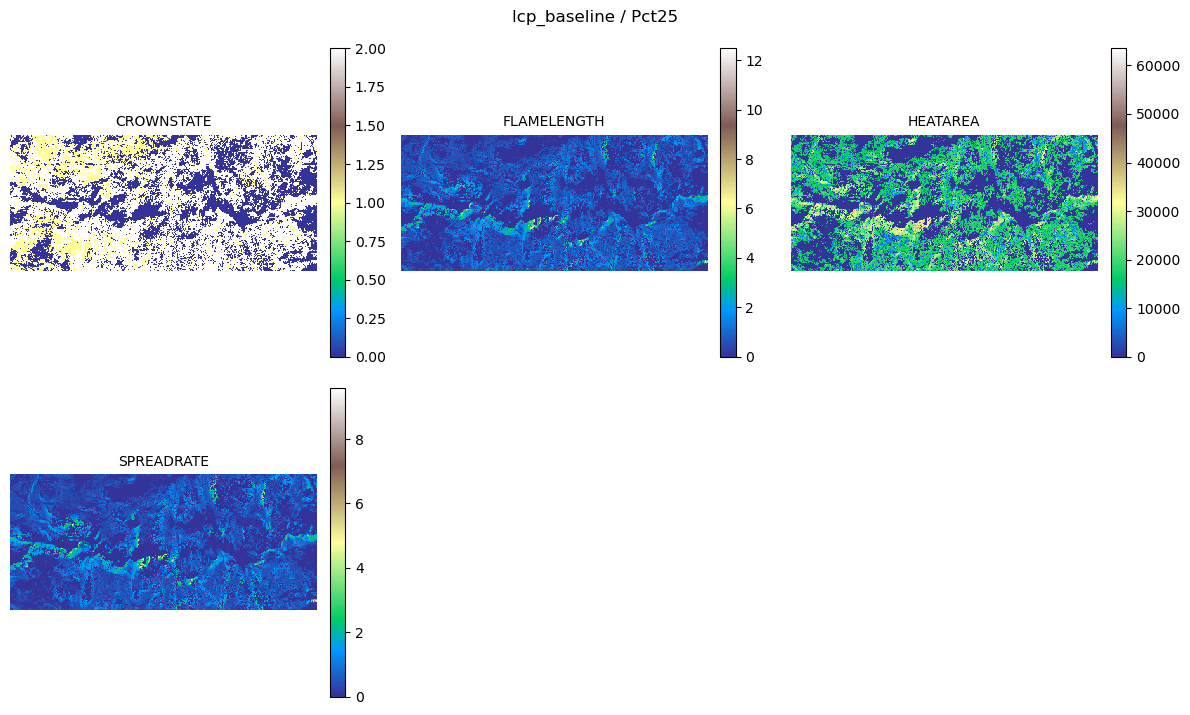

In [8]:
from fb_tools import run_batch, plot_bands
import rioxarray as rxr

# --- Run (works with df from either A or B above)
summary = run_batch(
    fm_exe=fm_exe,
    scenarios_df=scenarios_df,
    output_root=output_root,
    n_process=3,
    stack_out=True,    # stacks per-output TIFFs → one multiband file per run
    cleanup=True,      # removes the single-band TIFFs afterward
)

# --- Check for any failures
failures = summary[summary["status"] != "success"]
if not failures.empty:
    print("Failed runs:")
    print(failures[["Scenario", "LCP", "status"]])

# --- Inspect one result
row = summary.iloc[0]
stacked_tif = list(Path(row["output_dir"]).glob("*.tif"))[0]
da = rxr.open_rasterio(stacked_tif, masked=True)
fig, axes = plot_bands(da, cols=2)
fig.suptitle(f"{Path(row['LCP']).stem} / {row['Scenario']}", y=1.02)

## fetch_osm_roads module

In [ ]:
from fb_tools import fetch_osm_roads

roads, trails = fetch_osm_roads(aoi, out_crs=26913)
roads.plot()

## calculate_sdi module

In [ ]:
from fb_tools import calculate_sdi, calculate_delta_sdi

sdi_base = calculate_sdi(
    lcp=lcp_da,
    fb=os.path.join(projdir,'data/spatial/mod/flammap/outputs/lcp_baseline/Pct97/Pct97_LCP_BASELINE.tif'),
    roads_gdf=roads,
    trails_gdf=trails,
    rtc_path=os.path.join(projdir,'code/dev/SDI/08_RTC_lookup_SDIwt_westernUS_2021_update.txt')
)

## suppression module